# ETL Step

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

json_files = list(Path('data').glob('*.json'))
dfs = []

COLUMNS_TO_KEEP = [
    'ts',
    'platform',
    'ms_played',
    'conn_country',
    'master_metadata_album_artist_name',
    'master_metadata_album_album_name',
    'reason_start',
    'reason_end',
    'shuffle',
    'skipped',
    'offline'
]

for file in json_files:
    try:
        dfs.append(pd.read_json(file)[COLUMNS_TO_KEEP])
        print(f"Loaded {file.name} successfully.")
    except Exception as e:
        print(f"Error loading {file}: {e}")

df = pd.concat(dfs, ignore_index=True)

COLUMN_RENAME = {
    'ts': 'Timestamp',
    'platform': 'Platform',
    'ms_played': 'Time Played (ms)',
    'conn_country': 'Country',
    'master_metadata_album_artist_name': 'Artist Name',
    'master_metadata_album_album_name': 'Album Name',
    'reason_start': 'Reason Started',
    'reason_end': 'Reason Ended',
    'shuffle': 'Shuffle',
    'skipped': 'Skipped',
    'offline': 'Offline'
}
df.rename(columns=COLUMN_RENAME, inplace=True)

df['Platform Main'] = (
    df['Platform']
    .str.split()
    .str[0]
    .replace({
        'Partner': 'Android TV',
        'web_player': 'Web Player',
        'WebPlayer': 'Web Player'
    })
    .str.upper()    
)

df['Length_min'] = df['Time Played (ms)'] / 60000
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Year'] = df['Timestamp'].dt.year


Loaded Streaming_History_Audio_2014-2019_0.json successfully.
Loaded Streaming_History_Audio_2019-2020_1.json successfully.
Loaded Streaming_History_Audio_2020-2021_2.json successfully.
Loaded Streaming_History_Audio_2021-2022_3.json successfully.
Loaded Streaming_History_Audio_2022-2023_4.json successfully.
Loaded Streaming_History_Audio_2023-2024_5.json successfully.
Loaded Streaming_History_Audio_2024-2025_6.json successfully.
Loaded Streaming_History_Audio_2025-2026_9.json successfully.
Loaded Streaming_History_Audio_2025_7.json successfully.
Loaded Streaming_History_Audio_2025_8.json successfully.
Loaded Streaming_History_Video_2020-2026.json successfully.


# Platform Analysis
This section will anser to question which platform was utilized the most by me

I was quite surprised by the total amount of time I have spent on Spotify.
That's why I converted the listening time up to years to better understand the scale.

In [3]:
total_min = df['Length_min'].sum()

platform = (
    df.groupby('Platform Main')
    .agg(
        Length_min=('Length_min', 'sum'),
        Count=('Length_min', 'count')
    )
    .sort_values('Length_min', ascending=False)
)

platform = platform.assign(
    Length_hours=lambda x: x['Length_min'] / 60,
    Length_days=lambda x: x['Length_min'] / 1440,
    Length_months=lambda x: x['Length_min'] / 43200,
    Length_years=lambda x: x['Length_min'] / 525600,
    Time_pct=lambda x: (x['Length_min'] / total_min * 100),
    Count_pct=lambda x: (x['Count'] / x['Count'].sum() * 100),
    Avg_length_min=lambda x: x['Length_min'] / x['Count']
)

display(platform.round(2))

,Length_min,Count,Length_hours,Length_days,Length_months,Length_years,Time_pct,Count_pct,Avg_length_min
Platform Main,,,,,,,,,
ANDROID,213272.17,70604,3554.54,148.11,4.94,0.41,48.41,46.65,3.02
WINDOWS,125219.27,39623,2086.99,86.96,2.90,0.24,28.42,26.18,3.16
IOS,80889.34,31681,1348.16,56.17,1.87,0.15,18.36,20.93,2.55
WEB PLAYER,18144.44,8349,302.41,12.60,0.42,0.03,4.12,5.52,2.17
PLAYSTATION,1578.20,589,26.30,1.10,0.04,0.00,0.36,0.39,2.68
CAST,1114.75,332,18.58,0.77,0.03,0.00,0.25,0.22,3.36
UNKNOWN,216.40,81,3.61,0.15,0.01,0.00,0.05,0.05,2.67
ANDROID TV,162.54,80,2.71,0.11,0.00,0.00,0.04,0.05,2.03


# Year Analysis

2014 was excluded as there is not enough data to justify analysis, and there is a break in data continuity between 2014 and 2019

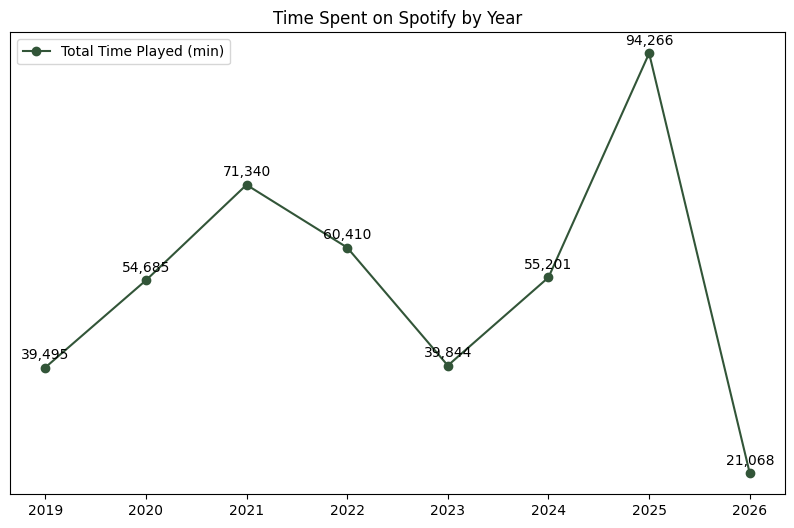

,Length_min,Count
Year,,
2019,39495.21,13405
2020,54685.14,17634
2021,71340.20,23635
2022,60409.64,18133
2023,39844.42,12800
2024,55201.41,18553
2025,94265.88,35096
2026,21067.78,8167


In [5]:
import matplotlib.pyplot as plt

df_years = df[df['Year'] != 2014]

years = (
    df_years.groupby('Year')
    .agg(
        Length_min=('Length_min', 'sum'),
        Count=('Length_min', 'count')
    )
).sort_index()

plt.figure(figsize=(10,6))

plt.plot(
    years.index,
    years['Length_min'],
    marker='o',
    label='Total Time Played (min)',
    color='#325538'
)

for x, y in zip(years.index, years['Length_min']):
    plt.text(x, y + 1000, f"{y:,.0f}", ha='center', va='bottom')

plt.gca().yaxis.set_visible(False)
plt.title("Time Spent on Spotify by Year")
plt.legend()
plt.show()

display(years.round(2))